# 🛒 Shopper Spectrum: Customer Segmentation & Product Recommendations
## Domain: E-Commerce and Retail Analytics
### Internship Project | Labmentix | Data Science with AI
---
**Objective:**  
Analyze e-commerce transaction data to:
1. Segment customers using RFM Analysis + KMeans Clustering
2. Build a Product Recommendation System using Collaborative Filtering

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [4]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/spectrum.csv')

print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom


## Step 2: Data Understanding
Checking missing values, duplicates, and unusual records before cleaning.

In [5]:
# Missing values check
print("Missing Values:\n", df.isnull().sum())

# Duplicate rows check
print("\nDuplicate Rows:", df.duplicated().sum())

# Unique counts
print("\nUnique Customers:", df['CustomerID'].nunique())
print("Unique Products:", df['StockCode'].nunique())
print("Unique Countries:", df['Country'].nunique())

# Quantity & UnitPrice stats (to spot negatives/zeros)
print("\nQuantity Stats:\n", df['Quantity'].describe())
print("\nUnitPrice Stats:\n", df['UnitPrice'].describe())

# Cancelled invoices (start with 'C')
cancelled = df[df['InvoiceNo'].astype(str).str.startswith('C')]
print("\nCancelled Invoices Count:", cancelled.shape[0])

Missing Values:
 InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate Rows: 5268

Unique Customers: 4372
Unique Products: 4070
Unique Countries: 38

Quantity Stats:
 count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

UnitPrice Stats:
 count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

Cancelled Invoices Count: 9288


## Step 3: Data Preprocessing / Cleaning
- Remove rows with missing CustomerID
- Exclude cancelled invoices (InvoiceNo starting with 'C')
- Remove negative or zero Quantity and UnitPrice

In [6]:
# Make a copy to keep original safe
df_clean = df.copy()

print("Before Cleaning:", df_clean.shape)

# 1. Remove missing CustomerID
df_clean = df_clean.dropna(subset=['CustomerID'])

# 2. Remove cancelled invoices (InvoiceNo starting with 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# 3. Remove negative or zero Quantity
df_clean = df_clean[df_clean['Quantity'] > 0]

# 4. Remove negative or zero UnitPrice
df_clean = df_clean[df_clean['UnitPrice'] > 0]

# 5. Convert CustomerID to int
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# 6. Convert InvoiceDate to datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print("After Cleaning:", df_clean.shape)
df_clean.head()

Before Cleaning: (541909, 8)
After Cleaning: (397884, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom


## Step 4: Exploratory Data Analysis (EDA)

Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64


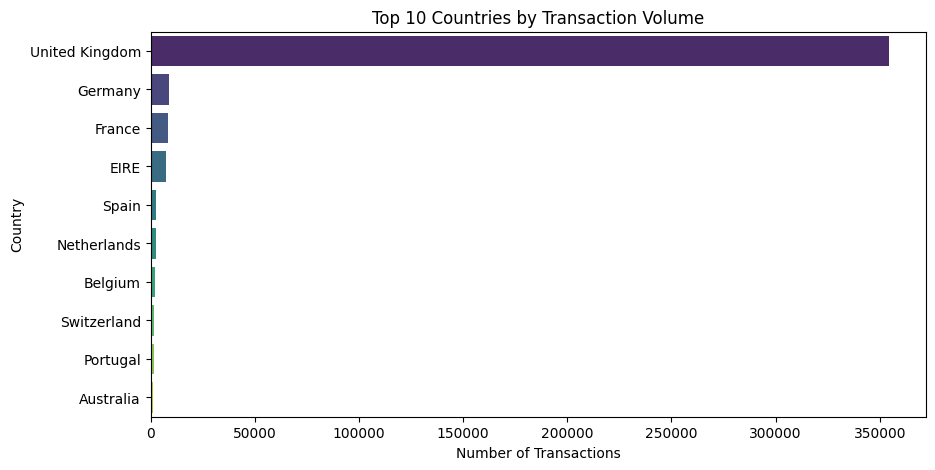

In [7]:
# Add TotalPrice column (needed for monetary analysis later too)
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

# Top 10 countries by transaction count
top_countries = df_clean['Country'].value_counts().head(10)
print(top_countries)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='viridis')
plt.title('Top 10 Countries by Transaction Volume')
plt.xlabel('Number of Transactions')
plt.ylabel('Country')
plt.show()

### Top-Selling Products
Identifying the most purchased products by quantity.

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
JUMBO BAG RED RETROSPOT               46181
WHITE HANGING HEART T-LIGHT HOLDER    36725
ASSORTED COLOUR BIRD ORNAMENT         35362
PACK OF 72 RETROSPOT CAKE CASES       33693
POPCORN HOLDER                        30931
RABBIT NIGHT LIGHT                    27202
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


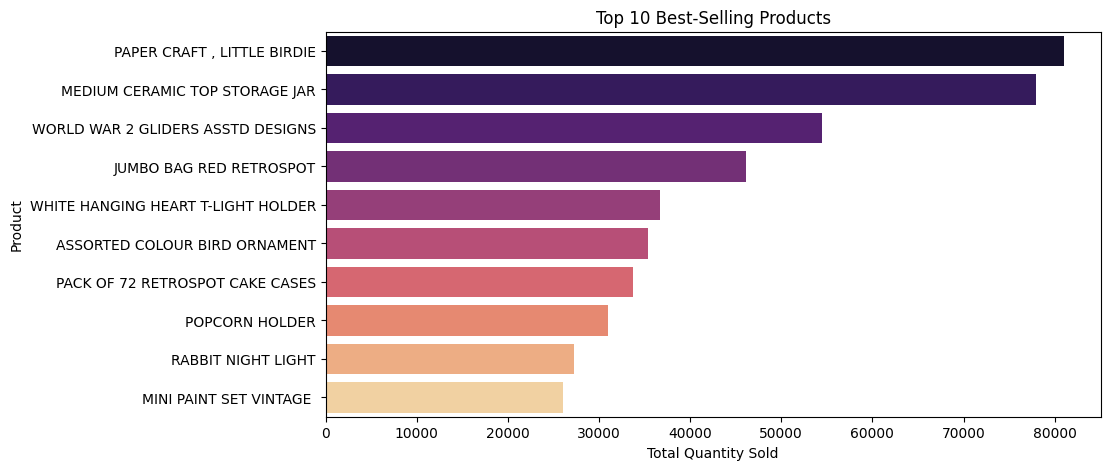

In [8]:
# Top 10 best-selling products by Quantity sold
top_products = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
print(top_products)

plt.figure(figsize=(10,5))
sns.barplot(x=top_products.values, y=top_products.index, palette='magma')
plt.title('Top 10 Best-Selling Products')
plt.xlabel('Total Quantity Sold')
plt.ylabel('Product')
plt.show()

### Purchase Trends Over Time
Visualizing monthly transaction trends to understand seasonality and growth patterns.

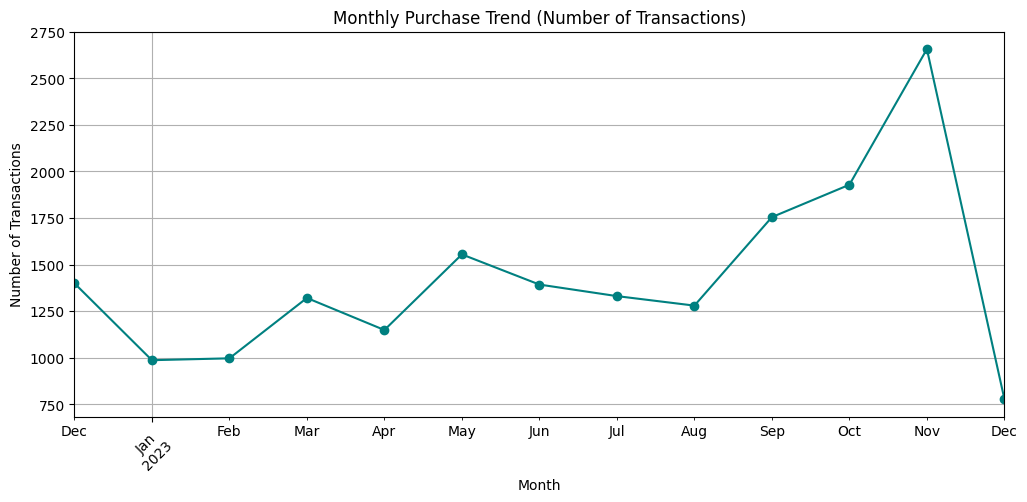

In [9]:
# Extract Year-Month from InvoiceDate
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

# Monthly transaction trend
monthly_trend = df_clean.groupby('YearMonth')['InvoiceNo'].nunique()

plt.figure(figsize=(12,5))
monthly_trend.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Purchase Trend (Number of Transactions)')
plt.xlabel('Month')
plt.ylabel('Number of Transactions')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

### Monetary Distribution
Inspecting spending patterns per transaction and per customer.

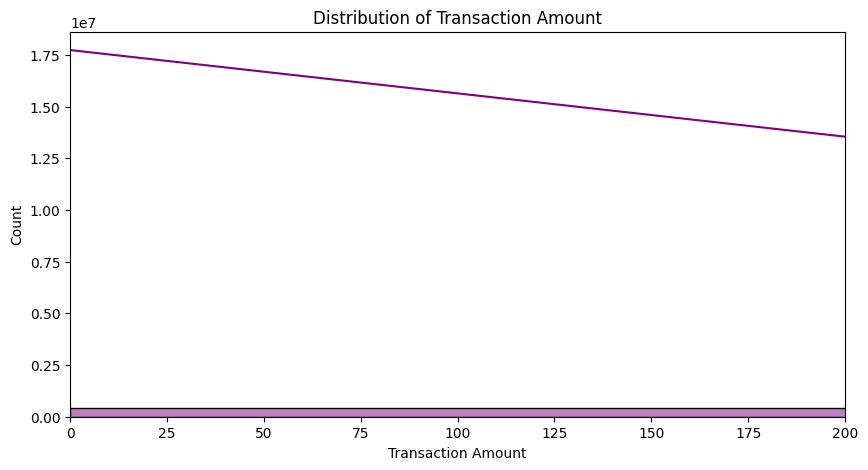

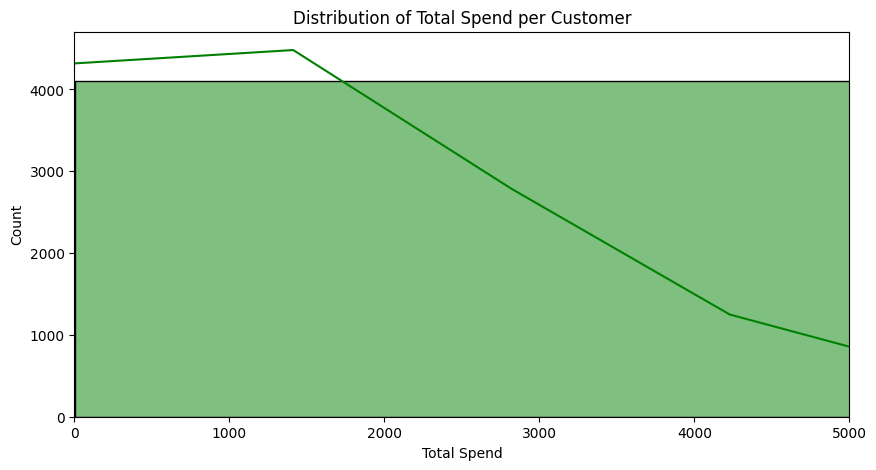

Customer Spend Summary:
 count      4338.000000
mean       2054.266460
std        8989.230441
min           3.750000
25%         307.415000
50%         674.485000
75%        1661.740000
max      280206.020000
Name: TotalPrice, dtype: float64


In [10]:
# Monetary distribution per transaction
plt.figure(figsize=(10,5))
sns.histplot(df_clean['TotalPrice'], bins=50, kde=True, color='purple')
plt.title('Distribution of Transaction Amount')
plt.xlabel('Transaction Amount')
plt.xlim(0, 200)   # zoom in to remove extreme outliers for clarity
plt.show()

# Monetary distribution per customer
customer_monetary = df_clean.groupby('CustomerID')['TotalPrice'].sum()

plt.figure(figsize=(10,5))
sns.histplot(customer_monetary, bins=50, kde=True, color='green')
plt.title('Distribution of Total Spend per Customer')
plt.xlabel('Total Spend')
plt.xlim(0, 5000)
plt.show()

print("Customer Spend Summary:\n", customer_monetary.describe())

## Step 5: Clustering Methodology

### 1️⃣ Feature Engineering: RFM (Recency, Frequency, Monetary)
- **Recency** = Days since customer's last purchase
- **Frequency** = Number of unique transactions per customer
- **Monetary** = Total amount spent by customer

In [11]:
# Reference date = one day after the latest transaction date in dataset
reference_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
print("Reference Date:", reference_date)

# Calculate RFM per customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,   # Recency
    'InvoiceNo': 'nunique',                                      # Frequency
    'TotalPrice': 'sum'                                          # Monetary
}).reset_index()

# Rename columns
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

print("RFM Table Shape:", rfm.shape)
rfm.head()

Reference Date: 2023-12-10 12:50:00
RFM Table Shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### RFM Distributions
Visualizing the spread of Recency, Frequency, and Monetary values across customers.

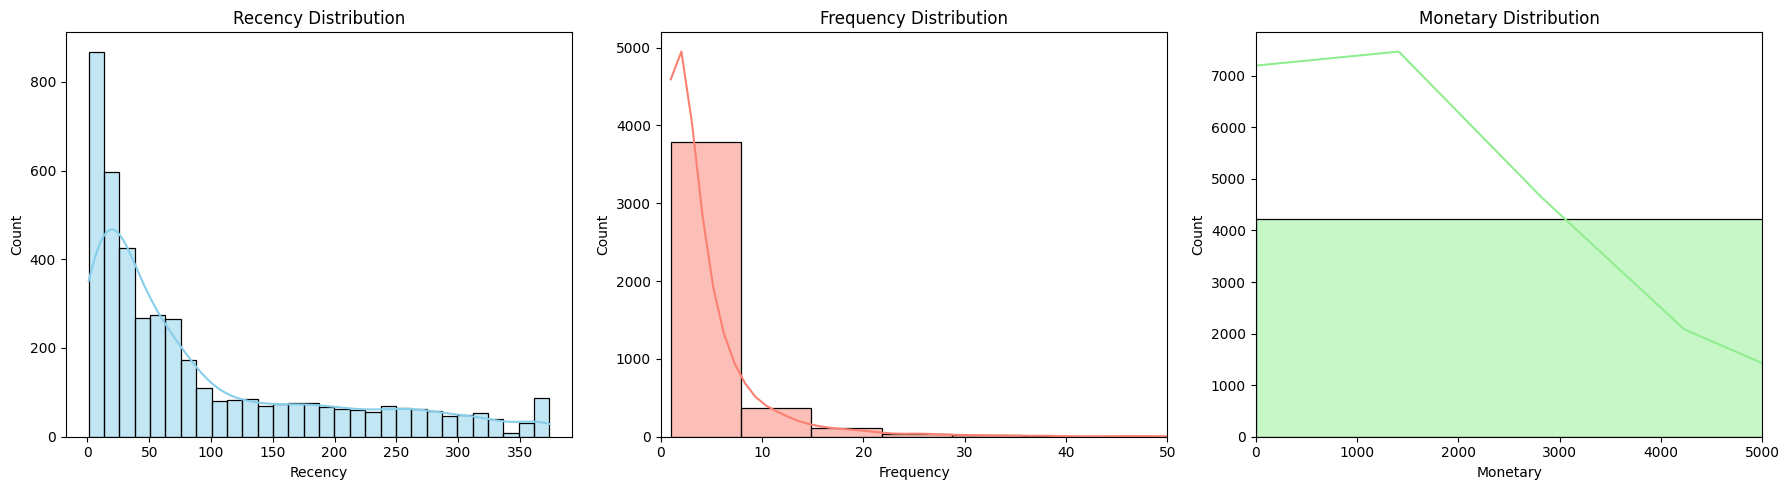

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

sns.histplot(rfm['Recency'], bins=30, kde=True, color='skyblue', ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], bins=30, kde=True, color='salmon', ax=axes[1])
axes[1].set_title('Frequency Distribution')
axes[1].set_xlim(0, 50)   # zoom in, remove extreme outliers for clarity

sns.histplot(rfm['Monetary'], bins=30, kde=True, color='lightgreen', ax=axes[2])
axes[2].set_title('Monetary Distribution')
axes[2].set_xlim(0, 5000)

plt.tight_layout()
plt.show()

rfm[['Recency','Frequency','Monetary']].describe()

### 2️⃣ Standardize RFM Values
### 3️⃣ Elbow Method — Choosing Optimal Number of Clusters

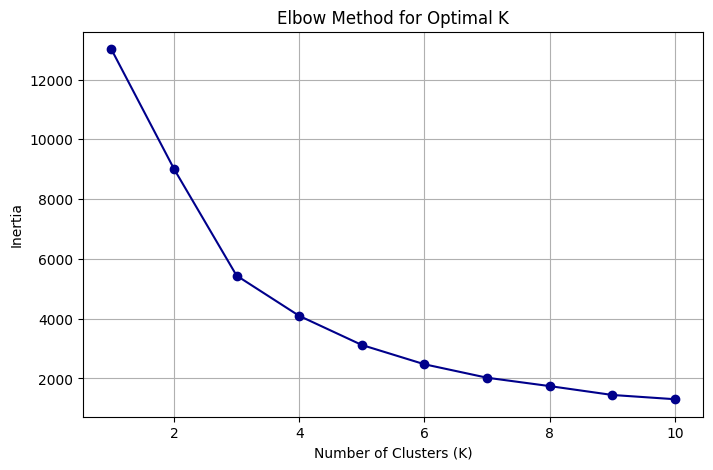

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Standardize RFM values
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency','Frequency','Monetary']])

# Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia, marker='o', color='darkblue')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

### 4️⃣ Silhouette Score — Confirming Optimal K

K=2, Silhouette Score=0.8958
K=3, Silhouette Score=0.5942
K=4, Silhouette Score=0.6162
K=5, Silhouette Score=0.6165
K=6, Silhouette Score=0.5963
K=7, Silhouette Score=0.5165
K=8, Silhouette Score=0.5175
K=9, Silhouette Score=0.4777
K=10, Silhouette Score=0.4271


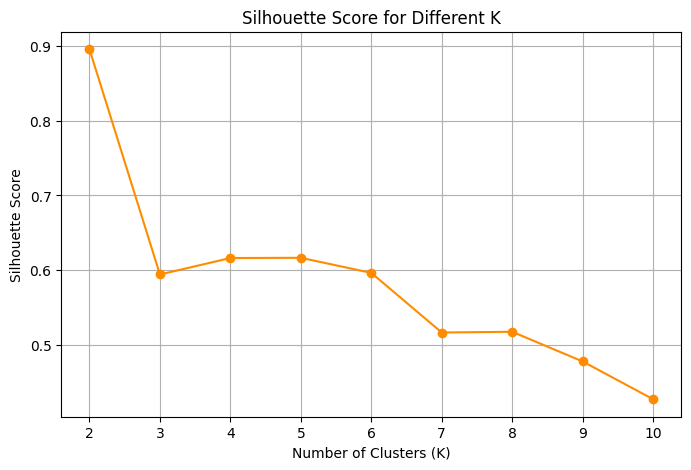

In [14]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range_sil = range(2, 11)

for k in K_range_sil:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    silhouette_scores.append(score)
    print(f"K={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(K_range_sil, silhouette_scores, marker='o', color='darkorange')
plt.title('Silhouette Score for Different K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

### 5️⃣ Final KMeans Model (K=4) & Cluster Labeling
We choose K=4 based on the Elbow Method and project requirement of 4 customer segments: High-Value, Regular, Occasional, At-Risk.

In [15]:
# Final KMeans model with K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled)

# Check average RFM per cluster
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
print(cluster_summary)

rfm['Cluster'].value_counts()

            Recency  Frequency       Monetary
Cluster                                      
0         43.702685   3.682711    1359.049284
1        248.075914   1.552015     480.617480
2          7.384615  82.538462  127338.313846
3         15.500000  22.333333   12709.090490


,count
Cluster,
0,3054
1,1067
3,204
2,13


### 6️⃣ Assign Segment Labels to Clusters

In [16]:
# Map cluster numbers to segment labels based on RFM characteristics
cluster_labels = {
    2: 'High-Value',
    3: 'Regular',
    0: 'Occasional',
    1: 'At-Risk'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

print(rfm['Segment'].value_counts())
rfm.head()

Segment
Occasional    3054
At-Risk       1067
Regular        204
High-Value      13
Name: count, dtype: int64


,CustomerID,Recency,Frequency,Monetary,Cluster,Segment
0,12346,326,1,77183.60,3,Regular
1,12347,2,7,4310.00,0,Occasional
2,12348,75,4,1797.24,0,Occasional
3,12349,19,1,1757.55,0,Occasional
4,12350,310,1,334.40,1,At-Risk


### 7️⃣ Cluster Visualization

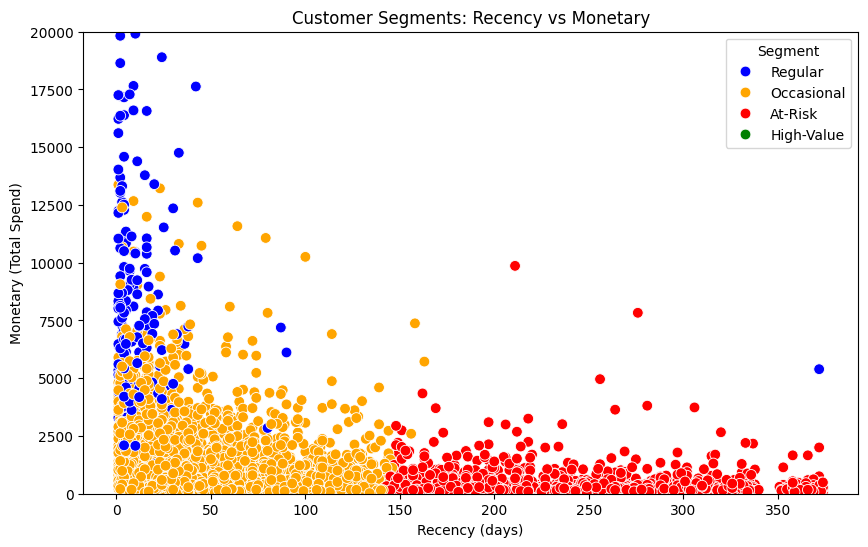

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette={'High-Value':'green','Regular':'blue','Occasional':'orange','At-Risk':'red'},
    s=60
)
plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (days)')
plt.ylabel('Monetary (Total Spend)')
plt.ylim(0, 20000)   # zoom in to see most customers clearly
plt.legend(title='Segment')
plt.show()

### 8️⃣ Save Model for Streamlit Usage

In [18]:
import pickle

# Save the trained KMeans model
with open('/content/drive/MyDrive/kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans_final, f)

# Save the scaler too (needed to transform new input the same way)
with open('/content/drive/MyDrive/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model and Scaler saved successfully to Google Drive!")

✅ Model and Scaler saved successfully to Google Drive!


## Step 6: Product Recommendation System
### Item-Based Collaborative Filtering using Cosine Similarity

In [19]:
# Create Customer-Product matrix (rows=CustomerID, columns=Product Description, values=Quantity purchased)
customer_product_matrix = df_clean.pivot_table(
    index='CustomerID',
    columns='Description',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

print("Matrix Shape:", customer_product_matrix.shape)
customer_product_matrix.head()

Matrix Shape: (4338, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
CustomerID,,,,,,,,,,,,,,,,,,,,,
12346,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12347,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12348,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12349,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
12350,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Compute Cosine Similarity Between Products

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

# Transpose: rows=Products, columns=Customers (so we compare products to each other)
product_customer_matrix = customer_product_matrix.T

# Compute cosine similarity between products
product_similarity = cosine_similarity(product_customer_matrix)

# Convert to DataFrame for easy lookup
product_similarity_df = pd.DataFrame(
    product_similarity,
    index=product_customer_matrix.index,
    columns=product_customer_matrix.index
)

print("Similarity Matrix Shape:", product_similarity_df.shape)
product_similarity_df.head()

Similarity Matrix Shape: (3877, 3877)


Description,4 PURPLE FLOCK DINNER CANDLES,50'S CHRISTMAS GIFT BAG LARGE,DOLLY GIRL BEAKER,I LOVE LONDON MINI BACKPACK,I LOVE LONDON MINI RUCKSACK,NINE DRAWER OFFICE TIDY,OVAL WALL MIRROR DIAMANTE,RED SPOT GIFT BAG LARGE,SET 2 TEA TOWELS I LOVE LONDON,SPACEBOY BABY GIFT SET,...,ZINC STAR T-LIGHT HOLDER,ZINC SWEETHEART SOAP DISH,ZINC SWEETHEART WIRE LETTER RACK,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS LARGE,ZINC T-LIGHT HOLDER STARS SMALL,ZINC TOP 2 DOOR WOODEN SHELF,ZINC WILLIE WINKIE CANDLE STICK,ZINC WIRE KITCHEN ORGANISER,ZINC WIRE SWEETHEART LETTER TRAY
Description,,,,,,,,,,,,,,,,,,,,,
4 PURPLE FLOCK DINNER CANDLES,1.000000,0.000000,0.000021,0.000227,0.000000,0.000000,0.020155,0.000000,0.000262,0.063396,...,0.0,0.001368,0.015886,0.001767,0.0,0.002846,0.0,0.013128,0.000000,0.002594
50'S CHRISTMAS GIFT BAG LARGE,0.000000,1.000000,0.003533,0.004001,0.000000,0.020034,0.027433,0.900849,0.119031,0.013380,...,0.0,0.001718,0.015572,0.018032,0.0,0.015710,0.0,0.011238,0.000000,0.029793
DOLLY GIRL BEAKER,0.000021,0.003533,1.000000,0.870851,0.980561,0.006296,0.005302,0.003034,0.001765,0.411331,...,0.0,0.000043,0.002869,0.344923,0.0,0.525860,0.0,0.822946,0.000097,0.006665
I LOVE LONDON MINI BACKPACK,0.000227,0.004001,0.870851,1.000000,0.883883,0.019879,0.004904,0.004043,0.008270,0.382056,...,0.0,0.001409,0.004197,0.310017,0.0,0.471717,0.0,0.749210,0.000000,0.010393
I LOVE LONDON MINI RUCKSACK,0.000000,0.000000,0.980561,0.883883,1.000000,0.000000,0.000000,0.000000,0.000000,0.410578,...,0.0,0.000000,0.000000,0.347021,0.0,0.530836,0.0,0.837170,0.000000,0.000000


### Function: Get Top 5 Similar Products
Given a product name, return the 5 most similar products based on cosine similarity.

In [21]:
def get_similar_products(product_name, top_n=5):
    if product_name not in product_similarity_df.columns:
        return f"Product '{product_name}' not found in dataset."

    # Get similarity scores for the given product, sorted descending
    similar_scores = product_similarity_df[product_name].sort_values(ascending=False)

    # Exclude the product itself, take top N
    top_similar = similar_scores.iloc[1:top_n+1]

    return top_similar

# Test the function
test_product = "WHITE HANGING HEART T-LIGHT HOLDER"
print(f"Top 5 products similar to: {test_product}\n")
print(get_similar_products(test_product))

Top 5 products similar to: WHITE HANGING HEART T-LIGHT HOLDER

Description
GIN + TONIC DIET METAL SIGN         0.750410
RED HANGING HEART T-LIGHT HOLDER    0.658719
WASHROOM METAL SIGN                 0.643500
LAUNDRY 15C METAL SIGN              0.642206
GREEN VINTAGE SPOT BEAKER           0.631461
Name: WHITE HANGING HEART T-LIGHT HOLDER, dtype: float64


### Save Similarity Matrix for Streamlit Usage

In [22]:
# Save the product similarity matrix
with open('/content/drive/MyDrive/product_similarity.pkl', 'wb') as f:
    pickle.dump(product_similarity_df, f)

print("✅ Product Similarity Matrix saved successfully to Google Drive!")

✅ Product Similarity Matrix saved successfully to Google Drive!


### Save Lightweight Similarity Data (Top 10 per product)

In [23]:
# Instead of saving the full huge matrix, save only top 10 similar products per product
top_similar_dict = {}

for product in product_similarity_df.columns:
    similar_scores = product_similarity_df[product].sort_values(ascending=False)
    top_10 = similar_scores.iloc[1:11]  # exclude itself, take top 10
    top_similar_dict[product] = list(zip(top_10.index, top_10.values))

# Save this lightweight dictionary
with open('/content/drive/MyDrive/top_similar_products.pkl', 'wb') as f:
    pickle.dump(top_similar_dict, f)

print("✅ Lightweight similarity data saved successfully!")

import os
file_size = os.path.getsize('/content/drive/MyDrive/top_similar_products.pkl') / (1024*1024)
print(f"File size: {file_size:.2f} MB")

✅ Lightweight similarity data saved successfully!
File size: 1.08 MB


### Customer Cluster Profiles Summary

In [24]:
# Final cluster profile summary
cluster_profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(2)
cluster_profile['Customer_Count'] = rfm.groupby('Segment')['CustomerID'].count()
print("Customer Segment Profiles:")
cluster_profile

Customer Segment Profiles:


,Recency,Frequency,Monetary,Customer_Count
Segment,,,,
At-Risk,248.08,1.55,480.62,1067
High-Value,7.38,82.54,127338.31,13
Occasional,43.70,3.68,1359.05,3054
Regular,15.50,22.33,12709.09,204
